# Tutorial: Training a Closure Model (Self-Contained)

This notebook demonstrates the full training workflow of the `closure` package using **small synthetic data**.
No external HDF5 files or CSV sample lists are required — everything is generated in-memory.

We cover:
1. Generating synthetic feature/target data
2. Configuring datasets, data loaders, and the MLP model
3. Training with the `Trainer` class
4. Evaluating predictions and plotting loss curves
5. Running additional runs with different hyper-parameters
6. Reloading a saved model

## 1. Imports

In [ ]:
import copy
import os
import shutil
from unittest.mock import patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from closure.config import TrainerConfig
from closure.trainers import Trainer
from closure import evaluation as ev

## 2. Generate Synthetic Data

We create small random arrays that mimic the shape returned by the data readers.
The shape convention is `(n_snapshots, ny, nx, n_channels)` — here we use a tiny 8×8 spatial grid
with 2 snapshots per split.

In [2]:
np.random.seed(42)

N_SNAPSHOTS = 2   # snapshots per split
NY, NX = 8, 8     # spatial dimensions
N_FEATURES = 3    # e.g. rho_e, Bx, By
N_TARGETS = 2     # e.g. Pxx_e, Pyy_e

FEATURE_NAMES = ["rho_e", "Bx", "By"]
TARGET_NAMES  = ["Pxx_e", "Pyy_e"]

def make_synthetic(n_snap, ny, nx, n_feat, n_targ):
    """Return (features, targets) arrays shaped (n_snap, ny, nx, channels)."""
    features = np.random.randn(n_snap, ny, nx, n_feat).astype(np.float64)
    # Targets = simple linear function of features + noise so the network can learn *something*
    flat_f = features.reshape(-1, n_feat)
    W = np.random.randn(n_feat, n_targ)
    targets = (flat_f @ W).reshape(n_snap, ny, nx, n_targ) + 0.1 * np.random.randn(n_snap, ny, nx, n_targ)
    return features.astype(np.float64), targets.astype(np.float64)

features_all, targets_all = make_synthetic(N_SNAPSHOTS, NY, NX, N_FEATURES, N_TARGETS)
print(f"features shape: {features_all.shape}")
print(f"targets  shape: {targets_all.shape}")

features shape: (2, 8, 8, 3)
targets  shape: (2, 8, 8, 2)


## 3. Prepare Working Directory

The `Trainer` reads a CSV listing the data snapshot filenames and calls `read_features_targets()` to
load them.  We will:
- Create a local working directory under `models/dev/tutorial/`
- Write a minimal CSV with dummy filenames
- **Mock** the reader function so it returns our synthetic arrays instead of loading real HDF5 files

In [ ]:
# Create a local working directory (inside models/dev/ which is gitignored)
WORK_DIR = os.path.join(os.path.dirname(os.getcwd()), "models", "dev", "tutorial")
os.makedirs(WORK_DIR, exist_ok=True)
print(f"Working directory: {WORK_DIR}")

# Write a dummy CSV (the filenames don't matter — we mock the reader)
csv_path = os.path.join(WORK_DIR, "split.csv")
pd.DataFrame({"filenames": ["snap_0.h5", "snap_1.h5"]}).to_csv(csv_path, index=False)
pd.read_csv(csv_path)

Working directory: /tmp/closure_tutorial_zewoc9ps


,filenames
0,snap_0.h5
1,snap_1.h5


## 4. Configure the Trainer

### 4a. Dataset keyword arguments

These tell the `DataFrameDataset` where the data lives and what channels to use.

In [4]:
dataset_kwargs = {
    "data_folder":     WORK_DIR,
    "train_sample":    csv_path,
    "val_sample":      csv_path,
    "test_sample":     csv_path,
    "flatten":         True,
    "scaler_features": True,
    "scaler_targets":  True,
    "image_file_name_column": "filenames",
    "read_features_targets_kwargs": {
        "request_features": FEATURE_NAMES,
        "request_targets":  TARGET_NAMES,
    },
}
dataset_kwargs

{'data_folder': '/tmp/closure_tutorial_zewoc9ps',
 'train_sample': '/tmp/closure_tutorial_zewoc9ps/split.csv',
 'val_sample': '/tmp/closure_tutorial_zewoc9ps/split.csv',
 'test_sample': '/tmp/closure_tutorial_zewoc9ps/split.csv',
 'flatten': True,
 'scaler_features': True,
 'scaler_targets': True,
 'image_file_name_column': 'filenames',
 'read_features_targets_kwargs': {'request_features': ['rho_e', 'Bx', 'By'],
  'request_targets': ['Pxx_e', 'Pyy_e']}}

### 4b. Data-loader keyword arguments

Control batch size, sub-sampling, and shuffling.

In [5]:
load_data_kwargs = {
    "train_loader_kwargs": {
        "batch_size":      32,
        "subsample_rate":  1.0,
        "subsample_seed":  42,
        "seed":            42,
        "shuffle":         True,
    },
    "val_loader_kwargs": {
        "batch_size":      32,
        "subsample_rate":  1.0,
        "subsample_seed":  42,
        "shuffle":         False,
    },
}

### 4c. Model keyword arguments

We use a small **MLP** (Multi-Layer Perceptron) with 2 hidden layers.  
Note: `feature_dims[0]` must equal `N_FEATURES` and `feature_dims[-1]` must equal `N_TARGETS`.

In [6]:
model_kwargs = {
    "model":         "MLP",
    "model_seed":    42,
    "feature_dims":  [N_FEATURES, 32, 16, N_TARGETS],
    "activations":   ["Tanh", "ReLU", None],
    "optimizer_kwargs": {
        "optimizer":  "Adam",
        "lr":         1e-3,
        "criterion":  "MSELoss",
    },
    "scheduler_kwargs": {
        "scheduler":      "ReduceLROnPlateau",
        "mode":           "min",
        "factor":         0.5,
        "patience":       5,
        "cooldown":       3,
        "epochs":         30,
        "early_stopping": 15,
    },
    "logger_kwargs": {"update_step": 5, "show": True},
}

## 5. Instantiate the Trainer (with Mocked Data)

The key trick: we `patch` the low-level reader so the `Trainer` receives our synthetic arrays
instead of trying to open real HDF5 files.

In [7]:
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)
    trainer = Trainer(
        work_dir=WORK_DIR,
        dataset_kwargs=dataset_kwargs,
        load_data_kwargs=load_data_kwargs,
        model_kwargs=model_kwargs,
    )

/users/cpa/georgem/miniforge3/envs/closure-test/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


### Inspect the created objects

In [8]:
print(f"Work dir:       {trainer.work_dir}")
print(f"Trainer:        {trainer}")
print(f"Train features: {trainer.train_dataset.features.shape}")
print(f"Train targets:  {trainer.train_dataset.targets.shape}")
print(f"Val features:   {trainer.val_dataset.features.shape}")
print(f"Test features:  {trainer.test_dataset.features.shape}")

Work dir:       /tmp/closure_tutorial_zewoc9ps
Trainer:        <closure.trainers.Trainer object at 0x7f1bf0b0f290>
Train features: torch.Size([128, 3])
Train targets:  torch.Size([128, 2])
Val features:   torch.Size([128, 3])
Test features:  torch.Size([128, 3])


In [9]:
print("Feature names:", trainer.train_dataset.request_features)
print("Target  names:", trainer.train_dataset.request_targets)
print("\nFeature mean:", torch.mean(trainer.train_dataset.features, dim=0))
print("Feature std: ", torch.std(trainer.train_dataset.features, dim=0))

Feature names: ['rho_e', 'Bx', 'By']
Target  names: ['Pxx_e', 'Pyy_e']

Feature mean: tensor([ 0.0000e+00,  1.3039e-08, -1.4901e-08])
Feature std:  tensor([1.0039, 1.0039, 1.0039])


## 6. Train the Model

Call `trainer.fit()` to run the training loop.  With 30 epochs on this tiny dataset it
completes in seconds.

In [10]:
# Enable logging output in the notebook so we can see training progress
import logging
logging.basicConfig(level=logging.INFO, force=True)

In [11]:
best_loss = trainer.fit()
print(f"\nBest validation loss: {best_loss:.6f}")

INFO:closure.trainers:Prior to fit: RAM memory % used: 6.8, RAM Used (GB): 18.455392256, process RAM usage (GB): 0.711395263671875
INFO:closure.models:Each forward pass had 4 train batches.
INFO:closure.models:Number of samples per batch: len(next(iter(train_loader))[0]) = 32
INFO:closure.models:Epoch 1/30 | Train loss: 1.0714e+00 | Val loss: 5.3007e-01 | Time/epoch: 1.923 s | Time/epoch_train: 0.954 s | Learn rate: [0.001]
INFO:closure.models:Epoch 5/30 | Train loss: 8.5029e-01 | Val loss: 4.0530e-01 | Time/epoch: 2.177 s | Time/epoch_train: 1.115 s | Learn rate: [0.001]
INFO:closure.models:Epoch 10/30 | Train loss: 6.1836e-01 | Val loss: 2.7763e-01 | Time/epoch: 1.987 s | Time/epoch_train: 1.005 s | Learn rate: [0.001]
INFO:closure.models:Epoch 15/30 | Train loss: 3.9409e-01 | Val loss: 1.6440e-01 | Time/epoch: 1.968 s | Time/epoch_train: 0.992 s | Learn rate: [0.001]
INFO:closure.models:Epoch 20/30 | Train loss: 2.0865e-01 | Val loss: 1.0718e-01 | Time/epoch: 2.082 s | Time/epoch_tr


Best validation loss: 0.103479


In [12]:
print("Files in work_dir:")
for f in sorted(os.listdir(WORK_DIR)):
    print(f"  {f}")

Files in work_dir:
  X.pkl
  config.json
  loss_dict.pkl
  model.pth
  split.csv
  training.log
  y.pkl


## 7. Plot Training / Validation Loss Curves

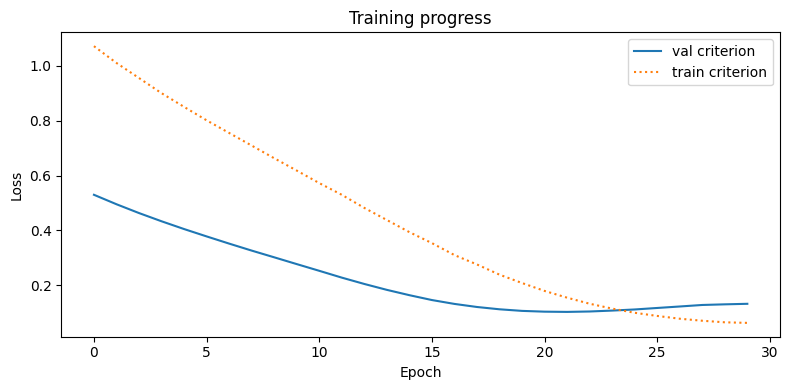

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for key, val_loss in trainer.model.val_loss_.items():
    ax.plot(val_loss, label=f"val {key}")
for key, train_loss in trainer.model.train_loss_.items():
    ax.plot(train_loss, label=f"train {key}", linestyle=":")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Training progress")
plt.tight_layout()
plt.show()

## 8. Evaluate on the Test Set

Use `transform_targets` to get un-normalized predictions and ground truth, then compute metrics.

In [14]:
ground_truth, predictions = ev.transform_targets(
    trainer, rescale=False, renorm=True, verbose=False, dataset="test"
)
print(f"Ground truth shape: {ground_truth.shape}")
print(f"Predictions  shape: {predictions.shape}")

Ground truth shape: (128, 2)
Predictions  shape: (128, 2)


In [15]:
# Per-channel MSE & R²
loss_mse = ev.evaluate_loss(trainer, ground_truth, predictions, "MSELoss")
print()
loss_r2  = ev.evaluate_loss(trainer, ground_truth, predictions, "r2")

Total loss 0.9087299543034257
Loss for channel 0: Pxx_e, loss = 0.17073595217906745
Loss for channel 1: Pyy_e, loss = 1.6467239564277842

Total loss -0.9928076434660094
Loss for channel 0: Pxx_e, loss = 0.7310374272655927
Loss for channel 1: Pyy_e, loss = -5.2320062347851515


### Scatter plot: Predictions vs Ground Truth

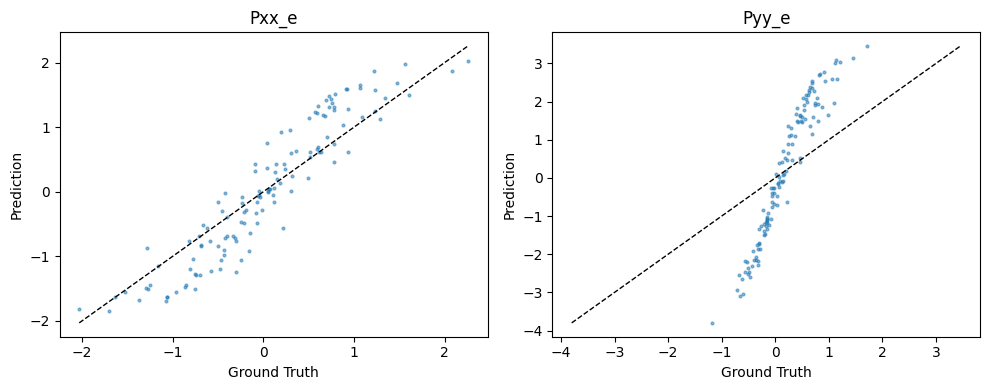

In [16]:
fig, axes = plt.subplots(1, N_TARGETS, figsize=(5 * N_TARGETS, 4))
if N_TARGETS == 1:
    axes = [axes]
for i, (ax, name) in enumerate(zip(axes, TARGET_NAMES)):
    gt_ch = ground_truth[:, i]
    pr_ch = predictions[:, i]
    ax.scatter(gt_ch, pr_ch, s=4, alpha=0.5)
    lims = [min(gt_ch.min(), pr_ch.min()), max(gt_ch.max(), pr_ch.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 9. Multiple Runs in the Same Trainer Folder

You can re-train with different hyper-parameters while keeping the same dataset.
Below we increase the number of epochs, change the learning rate, and store
the result in a sub-folder called `run2`.

In [17]:
config2 = copy.deepcopy(trainer.config)
config2["run"] = "run2"
config2["model_kwargs"]["optimizer_kwargs"]["lr"] = 5e-4
config2["model_kwargs"]["scheduler_kwargs"]["epochs"] = 50
config2["model_kwargs"]["logger_kwargs"]["show"] = True

best_loss_2 = trainer.fit(config=config2)
print(f"\nBest validation loss (run2): {best_loss_2:.6f}")

INFO:closure.trainers:Comprehending the configuration settings
INFO:closure.models:CUDA available: False
INFO:closure.models:Initialized model: MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)
INFO:closure.models:DDP not available, using single GPU: None
INFO:closure.models:Loss function: MSELoss()
INFO:closure.models:Optimizer: Adam with params: {'lr': 0.0005}
INFO:closure.models:Scheduler: ReduceLROnPlateau with params: {'mode': 'min', 'factor': 0.5, 'patience': 5, 'cooldown': 3}
INFO:closure.models:Training configuration complete for: <closure.models.PyNet object at 0x7f1be36b6c30>
INFO:closure.trainers:self.device = device(type='cpu') on self.local_rank = None
INFO:closure.trainers:Code version git hash: 1e92f93b85c7982d0520cabbe2e56


Best validation loss (run2): 0.094877


In [18]:
print("Files in work_dir:")
for root, dirs, files in os.walk(WORK_DIR):
    level = root.replace(WORK_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Files in work_dir:
closure_tutorial_zewoc9ps/
  X.pkl
  config.json
  loss_dict.pkl
  model.pth
  split.csv
  training.log
  y.pkl
  run2/
    config.json
    loss_dict.pkl
    model.pth
    run.log


### Compare loss curves of both runs

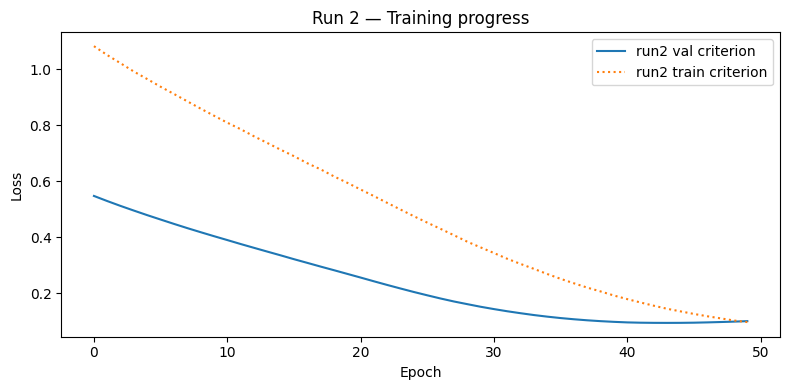

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
for key, val_loss in trainer.model.val_loss_.items():
    ax.plot(val_loss, label=f"run2 val {key}")
for key, train_loss in trainer.model.train_loss_.items():
    ax.plot(train_loss, label=f"run2 train {key}", linestyle=":")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Run 2 — Training progress")
plt.tight_layout()
plt.show()

## 10. Reload a Saved Model

Demonstrate that we can reload the trainer from disk (e.g. in a fresh session).
Because the data was mocked, we mock the reader again when re‑instantiating.

In [20]:
# Re-create the trainer from the saved config.json
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)
    trainer_reloaded = Trainer(work_dir=WORK_DIR)

# Load the second run's weights
trainer_reloaded.load_run("run2")
print(f"Reloaded run: {trainer_reloaded.run}")

INFO:closure.trainers: 
INFO:closure.trainers:===Logging to /tmp/closure_tutorial_zewoc9ps/training.log on level 20, @ self.rank=None, self.local_rank=None
INFO:closure.trainers:host: haydn.esat.kuleuven.be, self.device=device(type='cpu') ===
INFO:closure.trainers: 
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /tmp/closure_tutorial_zewoc9ps/split.csv
INFO:closure.datasets:Data shape - Features: (128, 3), Targets: (128, 2)
INFO:closure.datasets:Loaded normalization parameters for features from /tmp/closure_tutorial_zewoc9ps/X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Loaded normalization parameters for targets from /tmp/closure_tutorial_zewoc9ps/y.pkl
INFO:closure.datasets:Applying normalization to targets
INFO:closure.datasets: This is val set
INFO:closure.datasets:Loading data split from: /tmp/closure_tutorial_zewoc9ps/split.csv
INFO:closure.datasets:Data shape - Features: (128, 3), Targets: (128, 2)
I

Reloaded run: run2


In [21]:
# Get predictions from the reloaded model and compare metrics
gt_reload, pred_reload = ev.transform_targets(
    trainer_reloaded, rescale=False, renorm=True, verbose=False, dataset="test"
)
print(f"Prediction shape: {pred_reload.shape}  (same as original: {pred_reload.shape == predictions.shape})")
loss_reload = ev.evaluate_loss(trainer_reloaded, gt_reload, pred_reload, "MSELoss", verbose=True)

Prediction shape: (128, 2)  (same as original: True)
Total loss 1.1331400758011354
Loss for channel 0: Pxx_e, loss = 0.3401910800726464
Loss for channel 1: Pyy_e, loss = 1.9260890715296244


## 11. Clean Up

Remove the tutorial working directory (optional — it's inside `models/dev/` which is gitignored).

In [22]:
shutil.rmtree(WORK_DIR)
print(f"Cleaned up {WORK_DIR}")

Cleaned up /tmp/closure_tutorial_zewoc9ps


---

**Summary**

| Step | API used |
|------|----------|
| Create datasets + trainer | `Trainer(work_dir=..., dataset_kwargs=..., load_data_kwargs=..., model_kwargs=...)` |
| Train | `trainer.fit()` |
| New run (different hyper-params) | `trainer.fit(config=config2)` |
| Evaluate | `evaluation.transform_targets(trainer)`, `evaluation.evaluate_loss(...)` |
| Reload | `Trainer(work_dir=...)` then `trainer.load_run('run2')` |

For a tutorial that reads real PIC simulation data, see `tuto_train_haydn.ipynb`.